# 04 2D Segmentation

This notebook introduces the segmentation stage of the pipeline, focusing on the RGB stream. We will evaluate the performance of SAM2 for segmenting and tracking the forklift and kettle across the video frames.
We start with the **SAM2** Segmentation model as a baseline and evaluate to **SAM3** only if it provides a meaningful improvement without excessive computational cost.


### In this notebook, we will:

1. **RGB stream sanity check**
   - Load the `.vrs` file with `projectaria_tools`.
   - Validate RGB stream access and timestamp consistency.

2. **Prompt initialization frames**
   - Select only a few clean frames to initialize prompts.

3. **SAM2 baseline segmentation**
   - Multi-object prompting (forklift and kettle).
   - Mask propagation across time.

4. **Failure analysis and diagnostics**
   - Inspect drift, mask merging, holes, and missing thin parts.
   - Produce visual overlays for qualitative review.

5. **Targeted stress windows**
   - Evaluate difficult conditions: camera in/out motion, overlap, reflective kettle surfaces, and thin forklift structures.

6. **Quantitative temporal metrics**
   - Mask area stability, centroid jitter, temporal IoU, continuity/drop rate.

7. **SAM3 decision gate**
   - Run SAM3 only on critical windows.
   - Compare quality vs computational cost.

8. **Timestamp-aligned export**
   - Save masks and metadata with exact frame timestamps for later alignment with Aria trajectory/3D outputs.


As a sample, we will use `kettle_and_forklift_recording.vrs` located in the local `data/raw/kettle_and_forklift/` directory.

For this notebook, we used as references:
* SAM2: https://github.com/facebookresearch/sam2
* SAM3: https://github.com/facebookresearch/sam3


## 4.1 RGB Stream Sanity Check

In this section we will perform a sanity check on the RGB stream by defining input/output paths and reading one RGB frame to validate decoding and timestamps.

We will create a grid of RGB frames sampled every 10 seconds to visually inspect the video content and confirm that we can access the frames correctly.

We will use some helper functions defined in `scripts/aria_dataset.py`

In [19]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from projectaria_tools.core import data_provider

# depends on installed projectaria_tools build
try:
    from projectaria_tools.core.sensor_data import TimeDomain, TimeQueryOptions
except Exception:
    TimeDomain = None
    TimeQueryOptions = None

In [2]:
# setup paths and validate VRS access
VRS_PATH = os.path.join("..", "data", "raw", "kettle_and_forklift", "kettle_and_forklift_recording.vrs")

OUT_ROOT = os.path.join("..", "data", "outputs", "segmentation", "kettle_and_forklift")
Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

if not os.path.exists(VRS_PATH):
    raise FileNotFoundError(f"VRS file not found: {os.path.abspath(VRS_PATH)}")

print("VRS path:", os.path.abspath(VRS_PATH))
print("Output root:", os.path.abspath(OUT_ROOT))


VRS path: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\kettle_and_forklift\kettle_and_forklift_recording.vrs
Output root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\kettle_and_forklift


In [ ]:
# Helper functions for VRS access and RGB frame retrieval

from projectaria_tools.core import sensor_data
import sys
from pathlib import Path

# Import shared helpers from scripts/aria_dataset.py
from scripts.aria_dataset import _candidate_to_numpy_image, _extract_image_array_from_sample


def create_provider(vrs_path: str):
    """Create a VRS data provider for the given path."""
    provider = data_provider.create_vrs_data_provider(vrs_path)
    if provider is None:
        raise RuntimeError("Failed to create VRS data provider.")
    return provider


def resolve_rgb_stream(provider, rgb_stream_id_str: str = "214-1"):
    """Enumerate all streams and find the one matching the RGB stream id string."""
    rgb_candidates = [sid for sid in provider.get_all_streams() if str(sid) == rgb_stream_id_str]
    if len(rgb_candidates) == 0:
        raise RuntimeError(f"RGB stream {rgb_stream_id_str} not found in VRS.")
    rgb_stream_id = rgb_candidates[0]
    rgb_label = provider.get_label_from_stream_id(rgb_stream_id)
    rgb_sample_count = provider.get_num_data(rgb_stream_id)
    return rgb_label, rgb_stream_id, rgb_sample_count


def get_rgb_timestamps_ns(provider, stream_id, sample_count):
    """Get an array of timestamps in nanoseconds for all samples in the RGB stream."""
    ts = np.empty(sample_count, dtype=np.int64)
    for i in range(sample_count):
        s = provider.get_sensor_data_by_index(stream_id, i)
        ts[i] = s.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)
    return ts


def get_rgb_frame_by_index(provider, stream_id, index: int):
    """Get the RGB frame as a numpy array for the sample at the given index in the RGB stream."""
    sample = provider.get_sensor_data_by_index(stream_id, int(index))
    return _extract_image_array_from_sample(sample)

RGB stream label: camera-rgb
RGB stream id: 214-1
RGB sample count: 1551


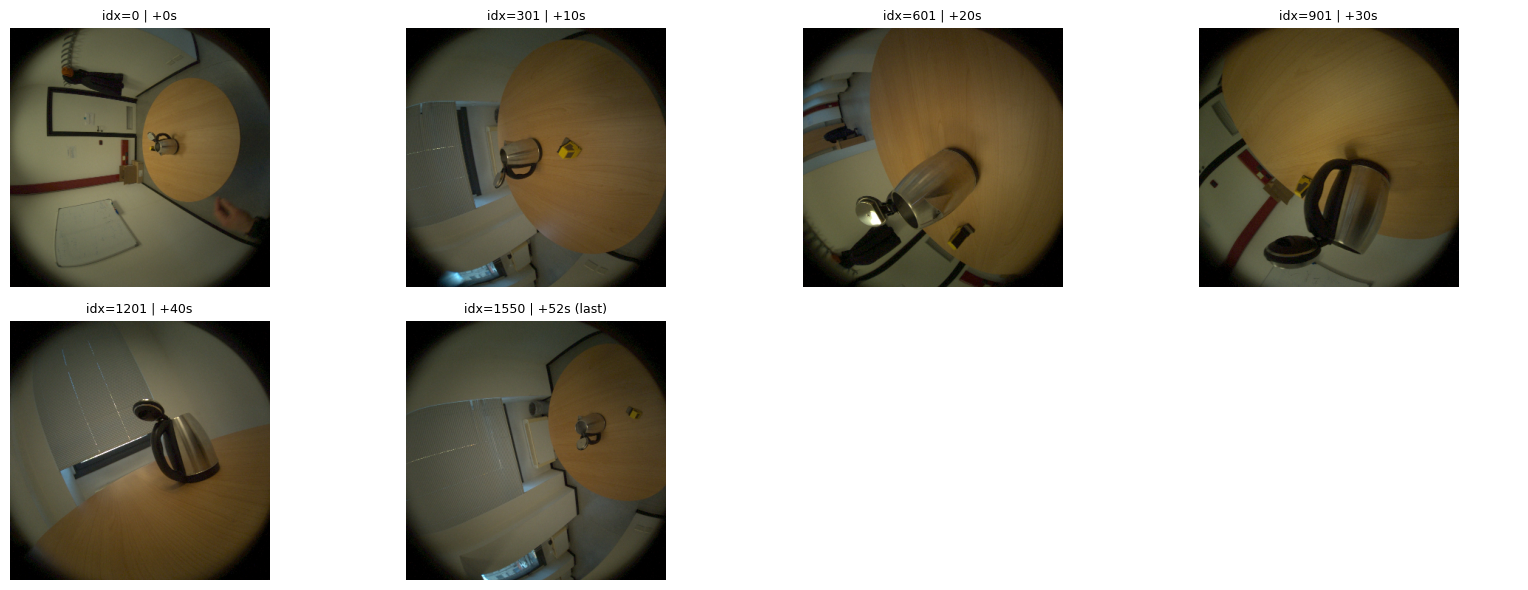

In [17]:
# as a sanity check we will create a grid with a frame every 10s

provider = create_provider(VRS_PATH)

rgb_label, rgb_stream_id, rgb_sample_count = resolve_rgb_stream(
    provider, rgb_stream_id_str="214-1"
)
rgb_timestamps_ns = get_rgb_timestamps_ns(provider, rgb_stream_id, rgb_sample_count)

print("RGB stream label:", rgb_label)
print("RGB stream id:", rgb_stream_id)
print("RGB sample count:", rgb_sample_count)

base_ts_ns = int(rgb_timestamps_ns[0])
last_ts_ns = int(rgb_timestamps_ns[-1])
duration_s = int((last_ts_ns - base_ts_ns) // 1_000_000_000)

step_s = 10
target_offsets_s = list(range(0, duration_s + 1, step_s))

# Get closest sample indices for target offsets
sample_indices = []
for off_s in target_offsets_s:
    target_ts_ns = base_ts_ns + off_s * 1_000_000_000
    idx = int(np.searchsorted(rgb_timestamps_ns, target_ts_ns, side="left"))
    if idx >= rgb_sample_count:
        idx = rgb_sample_count - 1
    sample_indices.append(idx)

# Force the last frame if it is not already included
if sample_indices[-1] != (rgb_sample_count - 1):
    sample_indices[-1] = rgb_sample_count - 1

# Remove duplicates while preserving order
seen = set()
sample_indices = [i for i in sample_indices if not (i in seen or seen.add(i))]

# Grid settings
downsample = 4  # 1=no resize, 2=1/2, 4=1/4
ncols = 4
nrows = (len(sample_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

# Display selected frames
for k in range(nrows * ncols):
    r, c = divmod(k, ncols)
    ax = axes[r, c]
    ax.axis("off")

    if k >= len(sample_indices):
        continue

    idx = sample_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]

    rel_s = int(round((int(rgb_timestamps_ns[idx]) - base_ts_ns) / 1e9))
    is_last = (idx == rgb_sample_count - 1)

    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s}s{' (last)' if is_last else ''}", fontsize=9)

plt.tight_layout()
plt.show()